# 02 — Automated extraction

The pipeline's *Extract* step: collect the publications of the four sources **without
manual intervention**, download the images, and write the whole thing as JSON.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

from dotenv import load_dotenv

load_dotenv(RACINE / ".env")

from multimodal_etl.logging_setup import setup_logging

setup_logging()

## 1. One source going down must not stop the others

`collect_sources` calls each connector inside its own `try/except` and keeps a tally: the
number of publications per source, `-1` on error. That tally is what feeds the "failed
sources" indicator of the monitoring plan.

In [2]:
from multimodal_etl.config import ExtractionConfig
from multimodal_etl.extract import collect_sources

publications, bilan = collect_sources(ExtractionConfig())
print(f"{len(publications)} publications collectées")
bilan

2026-08-20 12:01:52 | INFO    | multimodal_etl.extract | Extraction : démarrage de la source 'rss'


2026-08-20 12:01:52 | INFO    | multimodal_etl.sources.rss | RSS : lecture du flux 'the_guardian' (https://www.theguardian.com/world/rss)


2026-08-20 12:01:53 | INFO    | multimodal_etl.sources.rss | RSS : 45 publications recuperees depuis 'the_guardian'


2026-08-20 12:01:53 | INFO    | multimodal_etl.sources.rss | RSS : lecture du flux 'bbc_news' (https://feeds.bbci.co.uk/news/world/rss.xml)


2026-08-20 12:01:53 | INFO    | multimodal_etl.sources.rss | RSS : 27 publications recuperees depuis 'bbc_news'


...

2026-08-20 12:02:25 | INFO    | multimodal_etl.sources.kaggle_fakeddit | Fakeddit : 24 publications chargées depuis fakeddit_sample.tsv (échantillon de démonstration)


2026-08-20 12:02:25 | INFO    | multimodal_etl.extract | Extraction : source 'kaggle_fakeddit' -> 24 publications


2026-08-20 12:02:25 | INFO    | multimodal_etl.extract | Extraction : 179 publications brutes au total


179 publications collectées


{'rss': 97, 'newsdata': 10, 'fakenewsnet': 48, 'kaggle_fakeddit': 24}

## 2. What a connector returns

Every connector produces the **same structure**, whatever the data came from. That is what
lets the next step process them uniformly.

In [3]:
import pandas as pd

df_brut = pd.DataFrame(publications)
print("Colonnes :", list(df_brut.columns))
df_brut[["source", "source_type", "access_method"]].value_counts().to_frame("publications")

Colonnes : ['source', 'source_type', 'access_method', 'title', 'text', 'url', 'image_url', 'image_source', 'published_at', 'language', 'label', 'label_source']


,,,publications
source,source_type,access_method,
rss:the_guardian,rss,flux_rss,45
rss:bbc_news,rss,flux_rss,27
rss:abc_news,rss,flux_rss,25
fakenewsnet:politifact,dataset,telechargement_github,24
fakenewsnet:gossipcop,dataset,telechargement_github,24
fakeddit:fakenews,dataset,telechargement_kaggle,12
fakeddit:news,dataset,telechargement_kaggle,12
newsdata,api,api_rest,10


## 3. Download the images, not just their URLs

An image URL proves nothing: it can be dead, gated, or point at an HTML page. So the
pipeline **downloads** each image and opens it with Pillow before keeping it. Three
checks, cheapest first: the announced MIME type, the file size, then a real decode.

It is the path of the resulting file that gets recorded next to the text.

In [4]:
from multimodal_etl.config import ImageConfig
from multimodal_etl.images import download_images

compteurs = download_images(publications, ImageConfig())
compteurs

2026-08-20 12:02:45 | WARNING | multimodal_etl.images | Image : téléchargement impossible (https://www.mcknightsseniorliving.com/wp-content/uploads/sites/3/2021/10/GettyIm) : 403 Client Error: Forbidden for url: https://www.mcknightsseniorliving.com/wp-content/uploads/sites/3/2021/10/GettyImages-1251485244.jpg


2026-08-20 12:02:45 | WARNING | multimodal_etl.images | Image : téléchargement impossible (https://mmx.prnewswire.com/media/MS1118010/Rosen-Law-Firm-Logo.jpg?id=OA2898441&) : 403 Client Error: Forbidden for url: https://mmx.prnewswire.com/media/MS1118010/Rosen-Law-Firm-Logo.jpg?id=OA2898441&p=original


2026-08-20 12:02:46 | WARNING | multimodal_etl.images | Image : type 'text/html' refusé pour https://web.archive.org/web/20170702174006im_/http://freedomcrossroads.us/wp-con


2026-08-20 12:02:46 | WARNING | multimodal_etl.images | Image : téléchargement impossible (http://nationalreport.net/wp-content/uploads/2016/05/Target.jpg) : 404 Client Error: Not Found for url: https://nationalreport.net/wp-content/uploads/2016/05/Target.jpg


2026-08-20 12:02:47 | WARNING | multimodal_etl.images | Image : type 'text/html' refusé pour https://web.archive.org/web/20170731052757im_/http://politicspaper.com/wp-conten


...

2026-08-20 12:02:55 | WARNING | multimodal_etl.images | Image : téléchargement impossible (https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Vecteezy_stack-of-news) : 429 Client Error: Your bot is making too many requests. Please reduce your request rate or contact bot-traffic@wikimedia.org (f263c81) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Vecteezy_stack-of-newspaper_1961329.jpg/960px-Vecteezy_stack-of-newspaper_1961329.jpg


2026-08-20 12:02:55 | WARNING | multimodal_etl.images | Image : téléchargement impossible (https://upload.wikimedia.org/wikipedia/commons/5/52/Newspaper_bag.jpg) : 429 Client Error: Your bot is making too many requests. Please reduce your request rate or contact bot-traffic@wikimedia.org (f263c81) for url: https://upload.wikimedia.org/wikipedia/commons/5/52/Newspaper_bag.jpg


2026-08-20 12:02:55 | WARNING | multimodal_etl.images | Image : téléchargement impossible (https://upload.wikimedia.org/wikipedia/commons/1/1a/The_first_newspaper_%22Erkin) : 429 Client Error: Your bot is making too many requests. Please reduce your request rate or contact bot-traffic@wikimedia.org (f263c81) for url: https://upload.wikimedia.org/wikipedia/commons/1/1a/The_first_newspaper_%22Erkin-Too%22.jpg


2026-08-20 12:02:55 | INFO    | multimodal_etl.images | Images : 134 téléchargées, 9 échecs, 36 ignorées (11.4 Mo sur disque)


{'attempted': 143,
 'succeeded': 134,
 'failed': 9,
 'skipped': 36,
 'bytes': 11936547}

In [5]:
avec_fichier = [p for p in publications if p.get("image_path")]
print(f"{len(avec_fichier)} publications ont bien un fichier image")
exemple = avec_fichier[0]
print("Texte :", exemple["title"][:88])
print("Image :", exemple["image_path"])

134 publications ont bien un fichier image
Texte : More than 100 dead after goldmine collapses in Central African Republic
Image : data/raw/images/9b7c024c13d467b6.jpg


The text / image pair, shown as it will be handed to the model:

More than 100 dead after goldmine collapses in Central African Republic


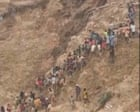

In [6]:
from IPython.display import Image, display

from multimodal_etl.config import absolute_path

print(exemple["title"])
display(Image(filename=str(absolute_path(exemple["image_path"])), width=420))

## 4. Saving the raw data

The format chosen is **JSON**, not CSV: a multimodal publication pairs a text with a file
path, and JSON keeps that structure unambiguous. The recorded path is **relative to the
project root**, so it stays valid somewhere other than the machine that produced it — the
pipeline runs locally as well as inside an Airflow container.

In [7]:
import json

from multimodal_etl.extract import save_raw

chemin_brut = save_raw(publications)
print("Écrit dans :", chemin_brut)
print(json.dumps(exemple, ensure_ascii=False, indent=2)[:600])

2026-08-20 12:02:55 | INFO    | multimodal_etl.extract | Extraction : 179 publications écrites dans C:\Users\Ben\Desktop\multimodal_etl\data\raw\raw_publications_20260820_100255.json


Écrit dans : C:\Users\Ben\Desktop\multimodal_etl\data\raw\raw_publications_20260820_100255.json
{
  "source": "rss:the_guardian",
  "source_type": "rss",
  "access_method": "rss_feed",
  "title": "More than 100 dead after goldmine collapses in Central African Republic",
  "text": "<p>The collapse was caused by a landslide, while local officials say the death toll is likely to rise as recovery efforts continue</p><p>More than 100 people have died after an artisanal goldmine at a small village in western Central African Republic (CAR) caved in due to a landslide, local officials and aid workers said on Wednesday.</p><p>The landslide happened on Tuesday afternoon in the village of Zamboye, 
